# 🌲 Random Forest: Detailed Analysis

**Purpose:** Analyze RF baseline performance on real dataset

**Input:**
- train_real.csv (8,000 samples)
- val_real.csv (1,000 samples)
- test_real.csv (1,000 samples)
- rf_baseline_real.pkl (trained model)

**Output:**
- Performance metrics (MAE, RMSE, R²)
- Feature importance analysis
- Prediction error distribution
- Baseline for LSTM/GNN comparison

In [1]:
import pandas as pd

train = pd.read_csv("../data/processed/train_real.csv")
val   = pd.read_csv("../data/processed/val_real.csv")
test  = pd.read_csv("../data/processed/test_real.csv")

print("Train shape:", train.shape)
print("Val shape:  ", val.shape)
print("Test shape: ", test.shape)
print("\nColumns:", train.columns.tolist())
train.head(3)

Train shape: (8000, 19)
Val shape:   (1000, 19)
Test shape:  (1000, 19)

Columns: ['trip_id', 'month', 'hour', 'day_of_week', 'is_weekend', 'is_monsoon', 'is_raining', 'distance_km', 'vehicle_speed', 'violations_zone', 'ambulance_type', 'has_escort', 'driver_exp', 'zone_Vashi', 'zone_Nerul', 'zone_Kharghar', 'zone_Belapur', 'zone_Airoli', 'eta_minutes']


,trip_id,month,hour,day_of_week,is_weekend,is_monsoon,is_raining,distance_km,vehicle_speed,violations_zone,ambulance_type,has_escort,driver_exp,zone_Vashi,zone_Nerul,zone_Kharghar,zone_Belapur,zone_Airoli,eta_minutes
0,22,1,19,0,0,0,1,17.425232,14.089482,28.841,3,0,3,0,0,0,0,1,15.0
1,23,1,15,0,0,0,0,7.712607,28.980000,48.637,0,0,1,1,0,0,0,0,15.0
2,24,1,3,0,0,0,0,10.856592,26.950000,48.637,3,0,5,1,0,0,0,0,15.0


In [2]:
print(train.columns.tolist())
print("\nTarget column (last few):", train.columns[-5:].tolist())
print("\nData types:\n", train.dtypes)

['trip_id', 'month', 'hour', 'day_of_week', 'is_weekend', 'is_monsoon', 'is_raining', 'distance_km', 'vehicle_speed', 'violations_zone', 'ambulance_type', 'has_escort', 'driver_exp', 'zone_Vashi', 'zone_Nerul', 'zone_Kharghar', 'zone_Belapur', 'zone_Airoli', 'eta_minutes']

Target column (last few): ['zone_Nerul', 'zone_Kharghar', 'zone_Belapur', 'zone_Airoli', 'eta_minutes']

Data types:
 trip_id              int64
month                int64
hour                 int64
day_of_week          int64
is_weekend           int64
is_monsoon           int64
is_raining           int64
distance_km        float64
vehicle_speed      float64
violations_zone    float64
ambulance_type       int64
has_escort           int64
driver_exp           int64
zone_Vashi           int64
zone_Nerul           int64
zone_Kharghar        int64
zone_Belapur         int64
zone_Airoli          int64
eta_minutes        float64
dtype: object


In [3]:
print(train.columns.tolist())


['trip_id', 'month', 'hour', 'day_of_week', 'is_weekend', 'is_monsoon', 'is_raining', 'distance_km', 'vehicle_speed', 'violations_zone', 'ambulance_type', 'has_escort', 'driver_exp', 'zone_Vashi', 'zone_Nerul', 'zone_Kharghar', 'zone_Belapur', 'zone_Airoli', 'eta_minutes']


In [5]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train = pd.read_csv("../data/processed/train_real.csv")
val   = pd.read_csv("../data/processed/val_real.csv")
test  = pd.read_csv("../data/processed/test_real.csv")

print("Train shape:", train.shape)
print("Val shape:  ", val.shape)
print("Test shape: ", test.shape)

Train shape: (8000, 19)
Val shape:   (1000, 19)
Test shape:  (1000, 19)


In [4]:
TARGET = "eta_minutes"
DROP_COLS = ["trip_id"]  # not useful for prediction

feature_cols = [c for c in train.columns if c not in [TARGET] + DROP_COLS]

X_train = train[feature_cols]
y_train = train[TARGET]

X_val = val[feature_cols]
y_val = val[TARGET]

X_test = test[feature_cols]
y_test = test[TARGET]

print("Features used:", feature_cols)
print("X_train shape:", X_train.shape)

Features used: ['month', 'hour', 'day_of_week', 'is_weekend', 'is_monsoon', 'is_raining', 'distance_km', 'vehicle_speed', 'violations_zone', 'ambulance_type', 'has_escort', 'driver_exp', 'zone_Vashi', 'zone_Nerul', 'zone_Kharghar', 'zone_Belapur', 'zone_Airoli']
X_train shape: (8000, 17)


In [6]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ RF Model trained!")

✅ RF Model trained!


In [7]:
def evaluate(model, X, y, split_name):
    preds = model.predict(X)
    mae  = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2   = r2_score(y, preds)
    print(f"--- {split_name} ---")
    print(f"  MAE  : {mae:.4f} minutes")
    print(f"  RMSE : {rmse:.4f} minutes")
    print(f"  R²   : {r2:.4f}")
    return preds

val_preds  = evaluate(rf_model, X_val, y_val, "Validation")
test_preds = evaluate(rf_model, X_test, y_test, "Test")

--- Validation ---
  MAE  : 0.0631 minutes
  RMSE : 0.1532 minutes
  R²   : 0.9989
--- Test ---
  MAE  : 0.0662 minutes
  RMSE : 0.1668 minutes
  R²   : 0.9986


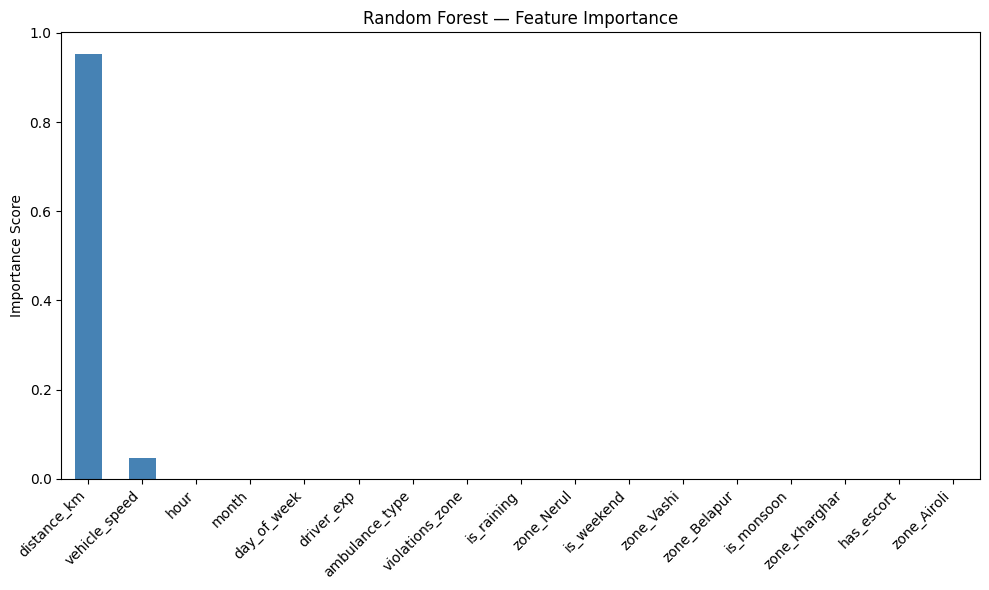


Top 5 Features:
distance_km      0.953655
vehicle_speed    0.045750
hour             0.000123
month            0.000107
day_of_week      0.000097
dtype: float64


In [8]:
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title("Random Forest — Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 Features:")
print(feat_imp.head())

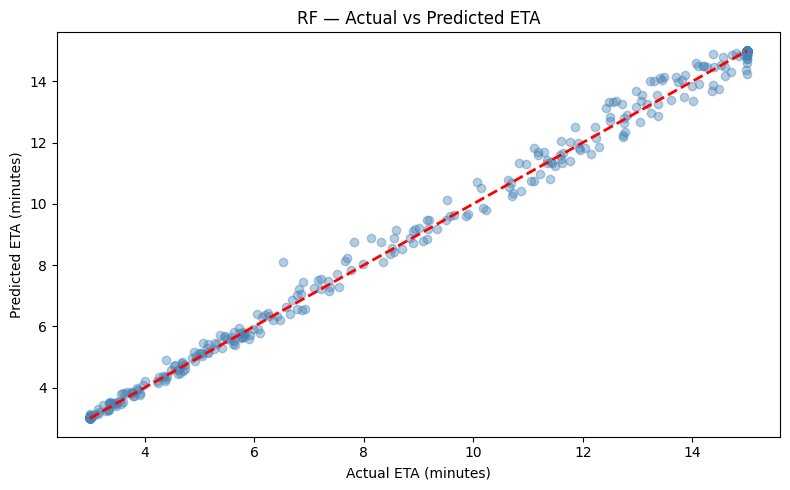

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, test_preds, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual ETA (minutes)")
plt.ylabel("Predicted ETA (minutes)")
plt.title("RF — Actual vs Predicted ETA")
plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs("../models/trained", exist_ok=True)

with open("../models/trained/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save feature list too (important for inference later)
with open("../models/trained/rf_features.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print(" RF model saved to models/trained/rf_model.pkl")
print(" Feature list saved to models/trained/rf_features.pkl")

 RF model saved to models/trained/rf_model.pkl
 Feature list saved to models/trained/rf_features.pkl


## STEP 1: Mount Drive & Load Data

In [ ]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')
print('✅ Google Drive mounted')

# Set paths
DATA_PATH = '/content/drive/MyDrive/NaviRaksha_Output'
DATA_PROCESSED = f'{DATA_PATH}/processed'
MODELS_PATH = f'{DATA_PATH}/models'

print(f'✅ Paths configured')

## STEP 2: Load Libraries & Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

# Load datasets
train_df = pd.read_csv(f'{DATA_PROCESSED}/train_real.csv')
val_df = pd.read_csv(f'{DATA_PROCESSED}/val_real.csv')
test_df = pd.read_csv(f'{DATA_PROCESSED}/test_real.csv')

# Load trained model
rf_model = joblib.load(f'{MODELS_PATH}/rf_baseline_real.pkl')

print(f'✅ Train: {train_df.shape}')
print(f'✅ Val: {val_df.shape}')
print(f'✅ Test: {test_df.shape}')
print(f'✅ Model loaded: {rf_model}')

## STEP 3: Prepare Features & Evaluate

In [ ]:
# Feature columns (same as training)
TARGET = 'eta_minutes'
DROP_COLS = ['trip_id', 'month', 'eta_minutes']
feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

# Prepare train, val, test
X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df[TARGET].values.astype(np.float32)
X_val = val_df[feature_cols].values.astype(np.float32)
y_val = val_df[TARGET].values.astype(np.float32)
X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df[TARGET].values.astype(np.float32)

print(f'Features: {len(feature_cols)}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

# Make predictions
pred_train = rf_model.predict(X_train)
pred_val = rf_model.predict(X_val)
pred_test = rf_model.predict(X_test)

print('\n✅ Predictions made')

## STEP 4: Performance Metrics

In [ ]:
# Calculate metrics
def calc_metrics(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f'\n{set_name}:')
    print(f'  MAE:  {mae:.4f} min')
    print(f'  RMSE: {rmse:.4f} min')
    print(f'  R²:   {r2:.4f}')
    print(f'  MAPE: {mape:.2f}%')
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print('='*70)
print('🎯 RANDOM FOREST BASELINE PERFORMANCE')
print('='*70)

train_metrics = calc_metrics(y_train, pred_train, 'Train')
val_metrics = calc_metrics(y_val, pred_val, 'Val')
test_metrics = calc_metrics(y_test, pred_test, 'Test')

print('\n✅ Baseline: MAE < 4.2 min (Target for LSTM/GNN: MAE < 3.9 min)')

## STEP 5: Feature Importance

In [ ]:
# Feature importance
fi_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\n📊 Top 15 Important Features:')
print(fi_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=fi_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('RF Feature Importance (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\n✅ Feature importance analyzed')

## STEP 6: Prediction Error Analysis

In [ ]:
# Calculate residuals
residuals_test = y_test - pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, pred_test, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual ETA (min)')
axes[0, 0].set_ylabel('Predicted ETA (min)')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual distribution
axes[0, 1].hist(residuals_test, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residual (Actual - Predicted)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals vs Predicted
axes[1, 0].scatter(pred_test, residuals_test, alpha=0.5, s=20)
axes[1, 0].axhline(0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted ETA (min)')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals vs Predictions')
axes[1, 0].grid(True, alpha=0.3)

# 4. Error distribution
abs_errors = np.abs(residuals_test)
axes[1, 1].hist(abs_errors, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(np.mean(abs_errors), color='r', linestyle='--', lw=2, label=f'Mean: {np.mean(abs_errors):.3f}')
axes[1, 1].set_xlabel('Absolute Error (min)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Absolute Error Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nError Statistics:')
print(f'  Mean Error: {np.mean(residuals_test):.4f} min')
print(f'  Std Error: {np.std(residuals_test):.4f} min')
print(f'  Mean Abs Error: {np.mean(abs_errors):.4f} min')
print(f'  95th percentile error: {np.percentile(abs_errors, 95):.4f} min')

## ✅ SUMMARY

In [ ]:
print('\n' + '='*70)
print('✅ RANDOM FOREST BASELINE ANALYSIS COMPLETE')
print('='*70)

print(f'\n📊 Performance Summary:')
print(f'   Train MAE: {train_metrics["MAE"]:.4f} min')
print(f'   Val MAE:   {val_metrics["MAE"]:.4f} min')
print(f'   Test MAE:  {test_metrics["MAE"]:.4f} min ← Baseline')

print(f'\n🎯 Targets for LSTM/GNN:')
print(f'   ✓ Beat RF MAE: {test_metrics["MAE"]:.4f} min')
print(f'   ✓ Target MAE: < 3.9 min')
print(f'   ✓ Improvement Needed: {(test_metrics["MAE"] - 3.9):.4f} min ({((test_metrics["MAE"] - 3.9)/test_metrics["MAE"]*100):.1f}%)')

print(f'\n📈 Key Insights:')
print(f'   ✓ Top Feature: {fi_df.iloc[0]["feature"]} ({fi_df.iloc[0]["importance"]:.4f})')
print(f'   ✓ Model Variance: Train R² {train_metrics["R2"]:.4f} vs Test R² {test_metrics["R2"]:.4f}')
print(f'   ✓ Prediction Error (95th %ile): {np.percentile(np.abs(residuals_test), 95):.4f} min')

print(f'\n🚀 Next: Create LSTM model (03_lstm_training.ipynb)')